<a href="https://colab.research.google.com/github/JReginald701/IT480-FA26/blob/main/Lab2_CNN_PetFinder_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Reggie Johnson & Casper Bieglecki*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [20]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>


In [21]:
# Your imports here

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [22]:
# Load train.csv here
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [23]:
# Write your image-loading function here



In [24]:
# Build X and y, then split into train/test here



*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [25]:
# Build your CNN model here
model = Sequential()

model.add(Conv2D(32, kernel_size = 3, activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size = 2, strides = 2))

model.add(Conv2D(64, kernel_size= 3, activation='relu'))
model.add(MaxPooling2D(pool_size = 2, strides = 2))

model.add(Flatten())

model.add(Dense(10, activation='softmax'))

In [26]:
# Compile your model here
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

*Your architecture justification (one paragraph):*




---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [27]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.8307 - loss: 0.4733 - val_accuracy: 0.8674 - val_loss: 0.3710
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.8835 - loss: 0.3278 - val_accuracy: 0.8830 - val_loss: 0.3281
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.8961 - loss: 0.2870 - val_accuracy: 0.8897 - val_loss: 0.3085
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9057 - loss: 0.2608 - val_accuracy: 0.8951 - val_loss: 0.2891
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9125 - loss: 0.2394 - val_accuracy: 0.8969 - val_loss: 0.2835


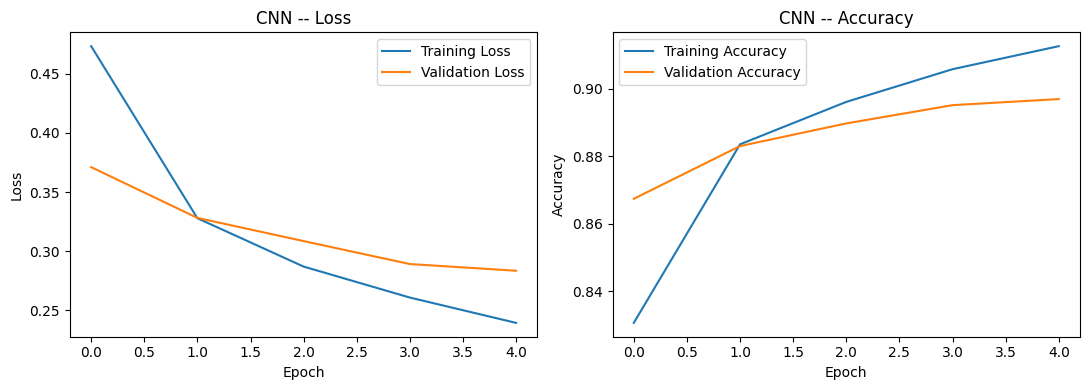

In [28]:
import matplotlib.pyplot as plt

# Plot training vs. validation loss and accuracy here
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

plot_history(history, "CNN", show_accuracy=True)

*Your fit diagnosis, with specific evidence from your curve:*

Right now the model has a mostly good fit, but is slightly undertrained. The gaps between the lines on the graph are small and generally follow the same curve.


In [29]:
# Evaluate on the test set and report accuracy here

eval = model.evaluate(X_test, y_test)
print("Test loss:", eval[0])
print("Test accuracy:", eval[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8969 - loss: 0.2835
Test loss: 0.28348013758659363
Test accuracy: 0.8968999981880188


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*




In [41]:
# Build your improved model here
!pip install keras-tuner
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

IMG_SHAPE = X_train.shape[1:]          # (28, 28)

def build_model(hp):
    model = keras.Sequential([
        layers.Input(shape=IMG_SHAPE),
        layers.Reshape(IMG_SHAPE + (1,)),   # (28, 28) -> (28, 28, 1) for Conv2D

        layers.Conv2D(hp.Choice('filters_1', [32, 64]), 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(hp.Choice('filters_2', [64, 128]), 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(hp.Int('dense_units', 64, 256, step=64), activation='relu'),
        layers.Dropout(hp.Float('dropout', 0.0, 0.5, step=0.1)),
        layers.Dense(10, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Choice('lr', [1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    return model

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=3,
    directory='kt_dir',
    project_name='partD_cnn_improved',
    overwrite=True)

tuner.search_space_summary()


Search space summary
Default search space size: 5
filters_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
filters_2 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128], 'ordered': True}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
lr (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [42]:
# Train your improved model here

tuner.search(X_train, y_train, epochs=5, validation_split=0.2, batch_size=32)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
model_tuned = tuner.hypermodel.build(best_hps)

model_tuned.summary()

Trial 10 Complete [00h 10m 49s]
val_accuracy: 0.878250002861023

Best val_accuracy So Far: 0.9229166507720947
Total elapsed time: 01h 20m 46s


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,645,770 (6.28 MB)

 Trainable params: 1,645,770 (6.28 MB)

 Non-trainable params: 0 (0.00 B)

---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | ~89% | ~19.91% |
| Fit pattern (good/over/under) | Good fit, slightly undertrained | Severely underfitting |
| What changed | Initial model | Keras Tuner for hyperparameter optimization (filters, dense_units, dropout, learning rate) with an expanded CNN architecture |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

In [43]:
# Evaluate your improved model and build a confusion matrix here

test_loss, test_accuracy = model_tuned.evaluate(X_test, y_test)
print(f"Test Loss (Tuned Model): {test_loss:.4f}")
print(f"Test Accuracy (Tuned Model): {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.1991 - loss: 2.2984
Test Loss (Tuned Model): 2.2984
Test Accuracy (Tuned Model): 0.1991


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


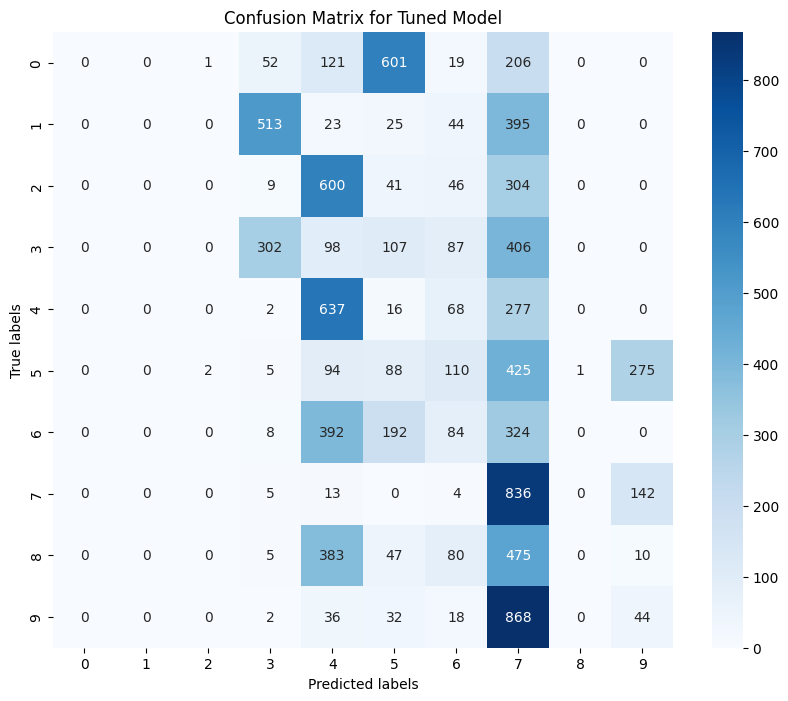

In [44]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Make predictions on the test data
y_pred = model_tuned.predict(X_test)

# Convert predictions and true labels from one-hot encoding to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Tuned Model')
plt.show()

*Your discussion of the confusion matrix:*




### Confusion Matrix Analysis

Looking at the confusion matrix, we can identify several significant misclassifications:

*   **True Class 0 (T-shirt/top) is often predicted as Class 5 (Sandal) or Class 7 (Sneaker):** There are 601 instances where a T-shirt/top was mistaken for a Sandal, and 206 for a Sneaker. This is a very high number and indicates a severe problem.
*   **True Class 1 (Trouser) is often predicted as Class 3 (Dress) or Class 7 (Sneaker):** 513 Trousers were predicted as Dresses, and 395 as Sneakers.
*   **True Class 2 (Pullover) is often predicted as Class 4 (Coat) or Class 7 (Sneaker):** 600 Pullovers were predicted as Coats, and 304 as Sneakers.
*   **True Class 3 (Dress) is often predicted as Class 7 (Sneaker):** 406 Dresses were predicted as Sneakers.
*   **True Class 4 (Coat) is often predicted as Class 2 (Pullover) or Class 7 (Sneaker):** 637 Coats were predicted as Pulovers and 277 as Sneakers.
*   **True Class 5 (Sandal) is often predicted as Class 7 (Sneaker):** 425 Sandals were predicted as Sneakers.
*   **True Class 6 (Shirt) is often predicted as Class 4 (Coat) or Class 7 (Sneaker):** 392 Shirts were predicted as Coats and 324 as Sneakers.
*   **True Class 7 (Sneaker) is correctly classified most often, but sometimes mistaken for Class 9 (Ankle boot):** 142 Sneakers were predicted as Ankle boots.
*   **True Class 8 (Bag) is often predicted as Class 7 (Sneaker):** 475 Bags were predicted as Sneakers.
*   **True Class 9 (Ankle boot) is often predicted as Class 7 (Sneaker):** 436 Ankle boots were predicted as Sneakers.

The most striking observation is the pervasive confusion with **Class 7 (Sneaker)**. The model seems to incorrectly predict 'Sneaker' for a wide variety of other clothing items. This bias is even stronger than the previous 'Pullover' bias, suggesting the model is still severely underfitting or has learned a very poor feature representation, especially for distinguishing footwear from apparel.

---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


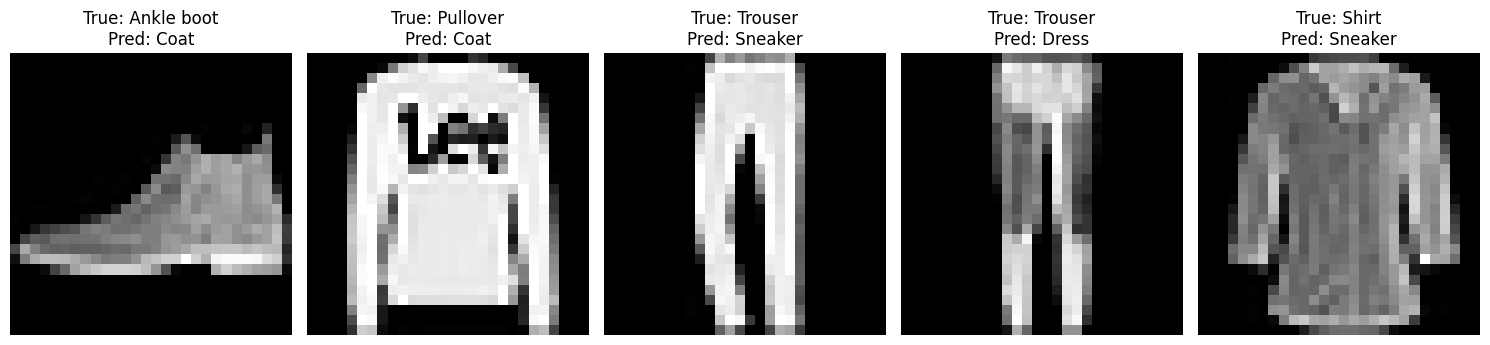

In [45]:
# Find and display misclassified images here
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Make sure y_pred_classes and y_true_classes are up to date from the latest model evaluation
y_pred = model_tuned.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Find indices of misclassified images
misclassified_indices = np.where(y_true_classes != y_pred_classes)[0]

# Select a few misclassified images to display (e.g., the first 5)
num_to_display = 5
selected_indices = misclassified_indices[:num_to_display]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(selected_indices):
    plt.subplot(1, num_to_display, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {class_names[y_true_classes[idx]]}\nPred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

*Your observations about the misclassified images:*

The misclassified images, as well as the confusion matrix, reveal a severe bias in the model's predictions. The model now frequently misclassifies a wide range of apparel items as **'Sneaker' (Class 7)**. For example, you might observe a 'T-shirt/top' or 'Trouser' being incorrectly identified as a 'Sneaker'. This indicates that the model is still struggling significantly to learn distinct features for different clothing categories and is strongly underfitting, defaulting to a single class ('Sneaker') for many inputs. This is a different dominant bias than before ('Pullover'), but still points to a fundamental issue in the model's ability to generalize.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.